In [7]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from enum import Enum
from copy import deepcopy

from scnn.optimize import optimize
from scnn.regularizers import NeuronGL1

class Device(str, Enum):
    CPU="cpu"; CUDA="cuda"; MPS="mps"

@dataclass
class CFG:
    tickers         = ("AAPL", "MSFT", "GOOG")
    prediction_cols = ("log_ret", "sigma20_log", "Volume")
    split_date      = "2018-01-02"
    p_lags          = 32
    calib_frac      = 0.20
    max_neurons     = 2_048
    lam_gl1         = 3e-5
    device          = Device.CPU
    data_dir        = Path(".")
    file_tpl        = "{tkr}_2005_2021_clean.csv"
    seed            = 42

CFG = CFG()                       # ← mutable instance

# ╔═════════════════════════════════════════════════════════════╗
#  1. CSV-loader that returns (train | calib | test) blocks
# ╚═════════════════════════════════════════════════════════════╝
def _flatten(tup):
    for lvl in tup:
        s = str(lvl).strip()
        if s and not s.lower().startswith("unnamed") and s != "nan":
            return s
    return "_".join(str(lvl).strip() for lvl in tup if str(lvl) != "nan")

def prepare_from_csv(path: Path, cfg: CFG = CFG):
    df = pd.read_csv(path, header=[0, 1], index_col=0, parse_dates=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [_flatten(t) for t in df.columns]
    df.index = df.index.normalize()

    # add log σ20 if absent
    if "sigma20" in df.columns and "sigma20_log" not in df.columns:
        df["sigma20_log"] = np.log1p(df["sigma20"])

    req = list(cfg.prediction_cols)
    if missing := [c for c in req if c not in df.columns]:
        raise KeyError(f"{path.name}: missing {missing}")

    split = df.index.get_loc(pd.to_datetime(cfg.split_date))

    # optional seasonality normalisation for Volume
    if "Volume" in req:
        roll = df["Volume"].shift(1).rolling(30, min_periods=1).median()
        df["Volume"] = df["Volume"] / roll

    # min-max scale on training window
    for c in req:
        lo, hi = df[c].iloc[:split].min(), df[c].iloc[:split].max()
        df[c] = (df[c] - lo) / (hi - lo)

    df = df[req].dropna()

    # lagged design
    X, tgt = [], {c: [] for c in req}
    for i in range(cfg.p_lags, len(df)):
        X.append(df.iloc[i - cfg.p_lags : i].values.flatten())
        for c in req:
            tgt[c].append(df.iloc[i][c])
    X = np.asarray(X)

    rel = split - cfg.p_lags
    cut = rel + int(cfg.calib_frac * (len(X) - rel))
    X_tr, X_cal, X_te = X[:rel], X[rel:cut], X[cut:]

    tgt_dict = {c: (np.asarray(v[:rel]),
                    np.asarray(v[rel:cut]),
                    np.asarray(v[cut:])) for c, v in tgt.items()}

    idx_cal  = df.index[cfg.p_lags:][rel:cut]
    idx_test = df.index[cfg.p_lags:][cut:]

    return (X_tr, X_cal, X_te, tgt_dict, idx_cal, idx_test)

# ╔═════════════════════════════════════════════════════════════╗
#  2. SCNN‐pinball fit  + 1-D CQR helper
# ╚═════════════════════════════════════════════════════════════╝
def fit_quantile(X_tr, X_cal, X_te,
                 y_tr, y_cal, y_te,
                 tau: float, cfg: CFG):
    mdl, _ = optimize(
        formulation   = "gated_relu",
        max_neurons   = cfg.max_neurons,
        X_train       = X_tr,   y_train = y_tr,
        X_test        = X_cal,  y_test  = y_cal,
        bias          = True,
        loss_type     = "pinball",
        pinball_tau   = tau,
        regularizer   = NeuronGL1(cfg.lam_gl1),
        device        = cfg.device,
        seed          = cfg.seed,
        verbose       = False,
    )
    return mdl, (mdl(X_tr).ravel(),
                 mdl(X_cal).ravel(),
                 mdl(X_te).ravel())

def cqr_univariate(Xb, yb, alpha=0.10, base_cfg: CFG = CFG):
    X_tr, X_cal, X_te = Xb
    y_tr, y_cal, y_te = yb

    # lower τ = α/2
    cfg_lo = deepcopy(base_cfg)
    _, q_lo = fit_quantile(X_tr, X_cal, X_te, y_tr, y_cal, y_te,
                           tau=alpha/2, cfg=cfg_lo)

    # upper τ = 1-α/2  (different seed for diversity)
    cfg_hi       = deepcopy(base_cfg)
    cfg_hi.seed += 777
    _, q_hi = fit_quantile(X_tr, X_cal, X_te, y_tr, y_cal, y_te,
                           tau=1 - alpha/2, cfg=cfg_hi)

    _, qlo_cal, qlo_te = q_lo
    _, qhi_cal, qhi_te = q_hi
    eps    = np.maximum(0.0,
               np.maximum(qlo_cal - y_cal, y_cal - qhi_cal))
    q_conf = np.quantile(eps, 1 - alpha)

    return {"lower": qlo_te - q_conf,
            "upper": qhi_te + q_conf,
            "truth": y_te}

# ╔═════════════════════════════════════════════════════════════╗
#  3. Build lag-blocks (once)
# ╚═════════════════════════════════════════════════════════════╝
blocks = {}
for tkr in CFG.tickers:
    path = CFG.data_dir / CFG.file_tpl.format(tkr=tkr)
    X_tr, X_cal, X_te, tgt, _, idx_test = prepare_from_csv(path, CFG)[:6]
    for col in CFG.prediction_cols:
        y_tr, y_cal, y_te = tgt[col]
        blocks[(tkr, col)] = ((X_tr, X_cal, X_te),
                              (y_tr, y_cal, y_te),
                              idx_test)
print("blocks ready")

# ╔════════════════════════════════════╗
#  4. Volume CQR → LOWER bound only
# ╚════════════════════════════════════╝
alpha   = 0.10
cqr_vol = {}

for tkr in CFG.tickers:
    Xb, yb, _    = blocks[(tkr, "Volume")]
    cqr_vol[tkr] = cqr_univariate(Xb, yb, alpha, CFG)

    cov = ((cqr_vol[tkr]["truth"] >= cqr_vol[tkr]["lower"])
         & (cqr_vol[tkr]["truth"] <= cqr_vol[tkr]["upper"])).mean()
    print(f"{tkr:<5}  Volume coverage = {cov:6.2%}")

# ---- day-by-day look-up ---------------------------------------------
T = len(next(iter(blocks.values()))[2])          # #days in test window
V_lower = {t: np.array([cqr_vol[tkr]["lower"][t] for tkr in CFG.tickers])
           for t in range(T)}
print("√  V_lower[t] ready  ➜  use  v_low = V_lower[t]")

blocks ready
AAPL   Volume coverage = 90.07%
MSFT   Volume coverage = 92.18%
GOOG   Volume coverage = 91.44%
√  V_lower[t] ready  ➜  use  v_low = V_lower[t]


## Volatility Coverage 

In [1]:
# ╔═════════════════════════════════════════════════════════════╗
#  0. Imports & Configuration
# ╚═════════════════════════════════════════════════════════════╝
import numpy as np, pandas as pd
from pathlib import Path
from dataclasses import dataclass
from enum      import Enum
from copy      import deepcopy
# ------------------------------------------------------------------
from scnn.optimize     import optimize
from scnn.regularizers import NeuronGL1
from scnn.models       import ConvexGatedReLU          # for weight copy
# ------------------------------------------------------------------
class Device(str, Enum):
    CPU = "cpu"; CUDA = "cuda"; MPS = "mps"

@dataclass
class CFG:
    tickers         = ("AAPL", "MSFT", "GOOG")
    prediction_cols = ("log_ret", "sigma20_log", "Volume")
    split_date      = "2018-01-02"
    p_lags          = 32
    calib_frac      = 0.20
    max_neurons     = 2_048
    lam_gl1         = 3e-5
    device          = Device.CPU
    data_dir        = Path(".")
    file_tpl        = "{tkr}_2005_2021_clean.csv"
    seed            = 42

CFG = CFG()                    # mutable instance

# ╔═════════════════════════════════════════════════════════════╗
#  1. Loader  →  (train | calib | test) blocks
# ╚═════════════════════════════════════════════════════════════╝
def _flatten(tup):
    for lvl in tup:
        s = str(lvl).strip()
        if s and not s.lower().startswith("unnamed") and s != "nan":
            return s
    return "_".join(str(lvl).strip() for lvl in tup if str(lvl) != "nan")

def prepare_from_csv(path: Path, cfg: CFG = CFG):
    df = pd.read_csv(path, header=[0, 1], index_col=0, parse_dates=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [_flatten(t) for t in df.columns]
    df.index = df.index.normalize()

    if "sigma20" in df.columns and "sigma20_log" not in df.columns:
        df["sigma20_log"] = np.log1p(df["sigma20"])

    req = list(cfg.prediction_cols)
    if missing := [c for c in req if c not in df.columns]:
        raise KeyError(f"{path.name}: missing {missing}")

    split = df.index.get_loc(pd.to_datetime(cfg.split_date))

    if "Volume" in req:
        roll = df["Volume"].shift(1).rolling(30, min_periods=1).median()
        df["Volume"] = df["Volume"] / roll

    for col in req:
        lo, hi = df[col].iloc[:split].min(), df[col].iloc[:split].max()
        df[col] = (df[col] - lo) / (hi - lo)

    df = df[req].dropna()

    # ---- lagged design --------------------------------------
    X, tgt = [], {c: [] for c in req}
    for i in range(cfg.p_lags, len(df)):
        X.append(df.iloc[i - cfg.p_lags : i].values.flatten())
        for c in req:
            tgt[c].append(df.iloc[i][c])
    X = np.asarray(X)

    rel  = split - cfg.p_lags
    cut  = rel + int(cfg.calib_frac * (len(X) - rel))
    X_tr, X_cal, X_te = X[:rel], X[rel:cut], X[cut:]

    tgt_dict = {c: (np.asarray(v[:rel]),
                    np.asarray(v[rel:cut]),
                    np.asarray(v[cut:])) for c, v in tgt.items()}

    idx_test = df.index[cfg.p_lags:][cut:]
    return X_tr, X_cal, X_te, tgt_dict, idx_test


# ╔═════════════════════════════════════════════════════════════╗
#  2. Quantile fit  + 1-D CQR helper
# ╚═════════════════════════════════════════════════════════════╝
def _get_weights(m):
    """
    Return a *copy* of the weight matrix stored inside an SCNN model,
    or None if the attribute name is unknown.
    """
    for attr in ("weights", "W", "coef_", "parameters"):
        w = getattr(m, attr, None)
        if w is None:
            continue

        # 1️⃣ torch tensor → NumPy
        if "torch" in type(w).__module__:
            w = w.detach().cpu().numpy()

        # 2️⃣ list/tuple of arrays → single stacked array
        if isinstance(w, (list, tuple)):
            try:
                w = np.vstack(w)
            except ValueError:
                continue  # inconsistent shapes → give up

        # 3️⃣ finally: coerce to ndarray & ensure 2-D
        try:
            w = np.asarray(w, dtype=float)
            if w.ndim == 1:                     # flat ⇒ no warm-start
                continue
            return w.copy()                     # SUCCESS
        except Exception:
            continue                            # try next attr

    return None                                  # nothing usable


def fit_quantile(X_tr, X_cal, X_te,
                 y_tr, y_cal, y_te,
                 *, tau: float, cfg: CFG,
                 warm_weights=None):

    mdl_cvx, _ = optimize(
        formulation   = "gated_relu",
        max_neurons   = cfg.max_neurons,
        X_train       = X_tr,  y_train = y_tr,
        X_test        = X_cal, y_test  = y_cal,
        bias          = True,
        loss_type     = "pinball",
        pinball_tau   = tau,
        regularizer   = NeuronGL1(cfg.lam_gl1),
        device        = cfg.device,
        seed          = cfg.seed,
        verbose       = False,
        return_convex = True,
    )

    # ---------- warm start: overwrite weights if compatible ------
    if warm_weights is not None:
        my_w = _get_weights(mdl_cvx)
        if my_w is not None and my_w.shape == warm_weights.shape:
            # setattr works for all attribute names
            for attr in ("weights", "W", "coef_", "parameters"):
                if hasattr(mdl_cvx, attr):
                    setattr(mdl_cvx, attr, warm_weights.copy())
                    break                      # done

    if hasattr(mdl_cvx, "prune_neurons"):
        mdl_cvx.prune_neurons(thr=5e-4)         # keeps width

    return mdl_cvx, (mdl_cvx(X_tr).ravel(),
                     mdl_cvx(X_cal).ravel(),
                     mdl_cvx(X_te).ravel())


def cqr_univariate(Xb, yb, *, alpha: float = 0.10, cfg: CFG):
    """
    Conformalised QR band (two-sided 1-α)
    """
    X_tr, X_cal, X_te = Xb
    y_tr, y_cal, y_te = yb

    # -------- lower quantile τ_lo = α/2 ---------------------------
    lo_mdl, q_lo = fit_quantile(X_tr, X_cal, X_te,
                                y_tr, y_cal, y_te,
                                tau=alpha/2, cfg=cfg)

    # -------- upper quantile τ_hi = 1-α/2  (reuse weights) --------
    w0           = _get_weights(lo_mdl)         # may be None – fine
    _, q_hi      = fit_quantile(X_tr, X_cal, X_te,
                                y_tr, y_cal, y_te,
                                tau=1 - alpha/2, cfg=cfg,
                                warm_weights=w0)

    # -------- conformal adjustment -------------------------------
    _, qlo_cal, qlo_te = q_lo
    _, qhi_cal, qhi_te = q_hi
    eps   = np.maximum(0.0,
             np.maximum(qlo_cal - y_cal, y_cal - qhi_cal))
    q_c   = np.quantile(eps, 1 - alpha)

    return {"lower": qlo_te - q_c,
            "upper": qhi_te + q_c,
            "truth": y_te}



def sig_cfg_for(tkr: str) -> CFG:
    cfg               = deepcopy(CFG)
    cfg.max_neurons   = 8_192
    cfg.lam_gl1       = 5e-6
    cfg.calib_frac    = 0.30
    cfg.seed          = 777 + hash(tkr) % 10_000
    return cfg


# ╔═════════════════════════════════════════════════════════════╗
#  3. Build lag-blocks once
# ╚═════════════════════════════════════════════════════════════╝
blocks = {}
for tkr in CFG.tickers:
    path = CFG.data_dir / CFG.file_tpl.format(tkr=tkr)
    X_tr, X_cal, X_te, tgt, idx_test = prepare_from_csv(path, CFG)
    for col in CFG.prediction_cols:
        y_tr, y_cal, y_te = tgt[col]
        blocks[(tkr, col)] = ((X_tr, X_cal, X_te),
                              (y_tr, y_cal, y_te),
                              idx_test)
print("blocks ready")

# ╔═════════════════════════════════════════════════════════════╗
#  4. σ₂₀ CQR (per-ticker hyper-params, **unchanged**)           #
# ╚═════════════════════════════════════════════════════════════╝
alpha      = 0.10
cqr_sig20  = {}

for tkr in CFG.tickers:
    Xb, yb, _      = blocks[(tkr, "sigma20_log")]
    cqr_sig20[tkr] = cqr_univariate(Xb, yb,
                                    alpha = alpha,
                                    cfg   = sig_cfg_for(tkr))

    cov   = ((cqr_sig20[tkr]["truth"] >= cqr_sig20[tkr]["lower"])
          &  (cqr_sig20[tkr]["truth"] <= cqr_sig20[tkr]["upper"])).mean()
    width = (cqr_sig20[tkr]["upper"] - cqr_sig20[tkr]["lower"]).mean()
    print(f"{tkr:<5}  σ20 cov={cov:6.2%}   mean-width={width:.4f}")

T = len(next(iter(blocks.values()))[2])
sigma_up = {t: np.array([cqr_sig20[tkr]["upper"][t]
                         for tkr in CFG.tickers])
            for t in range(T)}
print("sigma_up[t] ready  ➜  use  σ_hi = sigma_up[t]")


blocks ready
AAPL   σ20 cov=76.18%   mean-width=0.0948
MSFT   σ20 cov=86.10%   mean-width=0.0666
GOOG   σ20 cov=85.98%   mean-width=0.0688
sigma_up[t] ready  ➜  use  σ_hi = sigma_up[t]


In [2]:
plt.hist(cqr_sig20["AAPL"]["upper"] - cqr_sig20["AAPL"]["truth"],
         bins=40); plt.title("AAPL σ20 residual to upper band"); plt.show()

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3577, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2646/2764755832.py", line 1, in <module>
    plt.hist(cqr_sig20["AAPL"]["upper"] - cqr_sig20["AAPL"]["truth"],
    ^^^
NameError: name 'plt' is not defined

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 2168, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/IPython/core/ultratb.py", line 1457, in structured_traceback
    return FormattedTB.structured_traceback(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/I

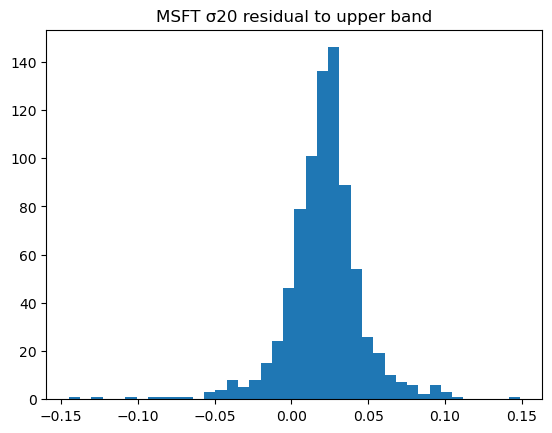

In [3]:
plt.hist(cqr_sig20["MSFT"]["upper"] - cqr_sig20["MSFT"]["truth"],
         bins=40); plt.title("MSFT σ20 residual to upper band"); plt.show()

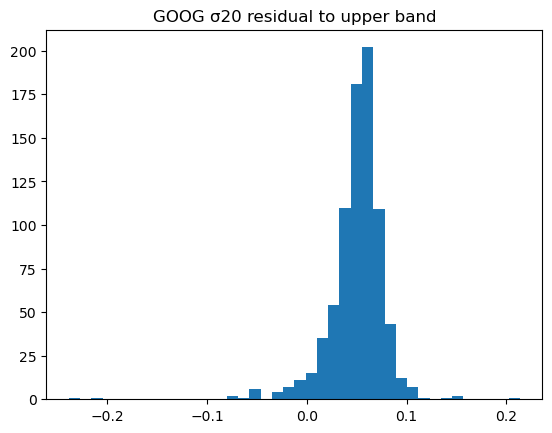

In [4]:
plt.hist(cqr_sig20["GOOG"]["upper"] - cqr_sig20["GOOG"]["truth"],
         bins=40); plt.title("GOOG σ20 residual to upper band"); plt.show()

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from enum import Enum
from copy import deepcopy

from scnn.optimize import optimize
from scnn.regularizers import NeuronGL1

class Device(str, Enum):
    CPU="cpu"; CUDA="cuda"; MPS="mps"

@dataclass
class CFG:
    tickers         = ("AAPL", "MSFT", "GOOG")
    prediction_cols = ("log_ret", "sigma20_log", "Volume")
    split_date      = "2018-01-02"
    p_lags          = 32
    calib_frac      = 0.20
    max_neurons     = 2_048
    lam_gl1         = 3e-5
    device          = Device.CPU
    data_dir        = Path(".")
    file_tpl        = "{tkr}_2005_2021_clean.csv"
    seed            = 42

CFG = CFG()                       # ← mutable instance

# ╔═════════════════════════════════════════════════════════════╗
#  1. CSV-loader that returns (train | calib | test) blocks
# ╚═════════════════════════════════════════════════════════════╝
def _flatten(tup):
    for lvl in tup:
        s = str(lvl).strip()
        if s and not s.lower().startswith("unnamed") and s != "nan":
            return s
    return "_".join(str(lvl).strip() for lvl in tup if str(lvl) != "nan")

def prepare_from_csv(path: Path, cfg: CFG = CFG):
    df = pd.read_csv(path, header=[0, 1], index_col=0, parse_dates=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [_flatten(t) for t in df.columns]
    df.index = df.index.normalize()

    # add log σ20 if absent
    if "sigma20" in df.columns and "sigma20_log" not in df.columns:
        df["sigma20_log"] = np.log1p(df["sigma20"])

    req = list(cfg.prediction_cols)
    if missing := [c for c in req if c not in df.columns]:
        raise KeyError(f"{path.name}: missing {missing}")

    split = df.index.get_loc(pd.to_datetime(cfg.split_date))

    # optional seasonality normalisation for Volume
    if "Volume" in req:
        roll = df["Volume"].shift(1).rolling(30, min_periods=1).median()
        df["Volume"] = df["Volume"] / roll

    # min-max scale on training window
    for c in req:
        lo, hi = df[c].iloc[:split].min(), df[c].iloc[:split].max()
        df[c] = (df[c] - lo) / (hi - lo)

    df = df[req].dropna()

    # lagged design
    X, tgt = [], {c: [] for c in req}
    for i in range(cfg.p_lags, len(df)):
        X.append(df.iloc[i - cfg.p_lags : i].values.flatten())
        for c in req:
            tgt[c].append(df.iloc[i][c])
    X = np.asarray(X)

    rel = split - cfg.p_lags
    cut = rel + int(cfg.calib_frac * (len(X) - rel))
    X_tr, X_cal, X_te = X[:rel], X[rel:cut], X[cut:]

    tgt_dict = {c: (np.asarray(v[:rel]),
                    np.asarray(v[rel:cut]),
                    np.asarray(v[cut:])) for c, v in tgt.items()}

    idx_cal  = df.index[cfg.p_lags:][rel:cut]
    idx_test = df.index[cfg.p_lags:][cut:]

    return (X_tr, X_cal, X_te, tgt_dict, idx_cal, idx_test)

# ╔═════════════════════════════════════════════════════════════╗
#  2. SCNN‐pinball fit  + 1-D CQR helper
# ╚═════════════════════════════════════════════════════════════╝
def fit_quantile(X_tr, X_cal, X_te,
                 y_tr, y_cal, y_te,
                 tau: float, cfg: CFG):
    mdl, _ = optimize(
        formulation   = "gated_relu",
        max_neurons   = cfg.max_neurons,
        X_train       = X_tr,   y_train = y_tr,
        X_test        = X_cal,  y_test  = y_cal,
        bias          = True,
        loss_type     = "pinball",
        pinball_tau   = tau,
        regularizer   = NeuronGL1(cfg.lam_gl1),
        device        = cfg.device,
        seed          = cfg.seed,
        verbose       = False,
    )
    return mdl, (mdl(X_tr).ravel(),
                 mdl(X_cal).ravel(),
                 mdl(X_te).ravel())

def cqr_univariate(Xb, yb, alpha=0.10, base_cfg: CFG = CFG):
    X_tr, X_cal, X_te = Xb
    y_tr, y_cal, y_te = yb

    # lower τ = α/2
    cfg_lo = deepcopy(base_cfg)
    _, q_lo = fit_quantile(X_tr, X_cal, X_te, y_tr, y_cal, y_te,
                           tau=alpha/2, cfg=cfg_lo)

    # upper τ = 1-α/2  (different seed for diversity)
    cfg_hi       = deepcopy(base_cfg)
    cfg_hi.seed += 777
    _, q_hi = fit_quantile(X_tr, X_cal, X_te, y_tr, y_cal, y_te,
                           tau=1 - alpha/2, cfg=cfg_hi)

    _, qlo_cal, qlo_te = q_lo
    _, qhi_cal, qhi_te = q_hi
    eps    = np.maximum(0.0,
               np.maximum(qlo_cal - y_cal, y_cal - qhi_cal))
    q_conf = np.quantile(eps, 1 - alpha)

    return {"lower": qlo_te - q_conf,
            "upper": qhi_te + q_conf,
            "truth": y_te}

# ╔═════════════════════════════════════════════════════════════╗
#  3. Build lag-blocks (once)
# ╚═════════════════════════════════════════════════════════════╝
blocks = {}
for tkr in CFG.tickers:
    path = CFG.data_dir / CFG.file_tpl.format(tkr=tkr)
    X_tr, X_cal, X_te, tgt, _, idx_test = prepare_from_csv(path, CFG)[:6]
    for col in CFG.prediction_cols:
        y_tr, y_cal, y_te = tgt[col]
        blocks[(tkr, col)] = ((X_tr, X_cal, X_te),
                              (y_tr, y_cal, y_te),
                              idx_test)
print("blocks ready")

def sig_cfg_for(tkr: str) -> CFG:
    cfg              = deepcopy(CFG)
    cfg.lam_gl1      = 2e-6          # ≈ zero sparsity
    cfg.max_neurons  = 12_288        # +50 %
    cfg.calib_frac   = 0.45          # almost half OOS -> calib
    cfg.seed         = 1_000 + hash(tkr) % 10_000
    return cfg

alpha = 0.10
cqr_sig20 = {}

for tkr in CFG.tickers:
    Xb, yb, _      = blocks[(tkr, "sigma20_log")]
    cqr_sig20[tkr] = cqr_univariate(Xb, yb, alpha, sig_cfg_for(tkr))

    cover = ((cqr_sig20[tkr]["truth"] >= cqr_sig20[tkr]["lower"])
           & (cqr_sig20[tkr]["truth"] <= cqr_sig20[tkr]["upper"])).mean()
    width = (cqr_sig20[tkr]["upper"] - cqr_sig20[tkr]["lower"]).mean()
    print(f"{tkr:<5}  σ20 cov={cover:6.2%}   mean-width={width:.4f}")

# ---- day-by-day look-up ---------------------------------------------
T = len(next(iter(blocks.values()))[2])
sigma_up = {t: np.array([cqr_sig20[tkr]["upper"][t] for tkr in CFG.tickers])
            for t in range(T)}
print("sigma_up[t] ready  ➜  use  σ_hi = sigma_up[t]")


In [ ]:
plt.hist(cqr_sig20["AAPL"]["upper"] - cqr_sig20["AAPL"]["truth"],
         bins=40); plt.title("AAPL σ20 residual to upper band"); plt.show()

In [ ]:
plt.hist(cqr_sig20["MSFT"]["upper"] - cqr_sig20["MSFT"]["truth"],
         bins=40); plt.title("MSFT σ20 residual to upper band"); plt.show()

In [ ]:
plt.hist(cqr_sig20["GOOG"]["upper"] - cqr_sig20["GOOG"]["truth"],
         bins=40); plt.title("GOOG σ20 residual to upper band"); plt.show()

## Old code

In [5]:
for tkr in CFG.tickers:
    width = (cqr_sig20[tkr]["upper"] - cqr_sig20[tkr]["lower"]).mean()
    print(f"{tkr:<5}  σ20 mean-width = {width:.4f}")

AAPL   σ20 mean-width = 0.0959
MSFT   σ20 mean-width = 0.0768
GOOG   σ20 mean-width = 0.0758


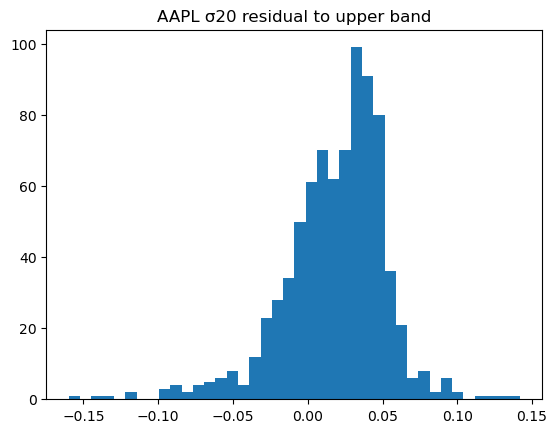

In [6]:
plt.hist(cqr_sig20["AAPL"]["upper"] - cqr_sig20["AAPL"]["truth"],
         bins=40); plt.title("AAPL σ20 residual to upper band"); plt.show()

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from enum import Enum
from copy import deepcopy

from scnn.optimize import optimize
from scnn.regularizers import NeuronGL1

class Device(str, Enum):
    CPU="cpu"; CUDA="cuda"; MPS="mps"

@dataclass
class CFG:
    tickers         = ("AAPL", "MSFT", "GOOG")
    prediction_cols = ("log_ret", "sigma20", "Volume")
    split_date      = "2018-01-02"      # first OOS day
    p_lags          = 32
    calib_frac      = 0.20             # 20 % of OOS → calibration
    max_neurons     = 2048
    lam_gl1         = 3e-5
    device          = Device.CPU
    data_dir        = Path(".")
    file_tpl        = "{tkr}_2005_2021_clean.csv"
    seed            = 42               # base seed

CFG = CFG()                 # instantiate a *mutable* object

# ╔═════════════════════════════════════════════════════════════╗
#  Helper: flatten header + loader that returns 3 blocks
# ╚═════════════════════════════════════════════════════════════╝
def _flatten(col_tup):
    for lvl in col_tup:
        s = str(lvl).strip()
        if s and not s.lower().startswith("unnamed") and s != "nan":
            return s
    return "_".join(str(lvl).strip() for lvl in col_tup if str(lvl) != "nan")

def prepare_from_csv(file_path: Path, cfg: CFG = CFG):
    df = pd.read_csv(file_path, header=[0, 1], index_col=0, parse_dates=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [_flatten(t) for t in df.columns]
    df.index = df.index.normalize()

    req = list(cfg.prediction_cols)
    if missing := [c for c in req if c not in df.columns]:
        raise KeyError(f"{file_path.name}: missing {missing}")

    split_idx = df.index.get_loc(pd.to_datetime(cfg.split_date))

    # -------------- optional seasonality normalisation -------------
    seasonality = {}
    if "Volume" in req:
        roll = df["Volume"].shift(1).rolling(30, min_periods=1).median()
        df["Volume"] = df["Volume"] / roll
        seasonality["Volume"] = roll

    # -------------- min–max scale (on training window only) --------
    for col in req:
        lo = df[col].iloc[:split_idx].min()
        hi = df[col].iloc[:split_idx].max()
        df[col] = (df[col] - lo) / (hi - lo)

    # -------------- lag-matrix design ------------------------------
    df = df[req].dropna()
    X, tgt = [], {c: [] for c in req}
    for i in range(cfg.p_lags, len(df)):
        X.append(df.iloc[i-cfg.p_lags:i].values.flatten())
        for col in req:
            tgt[col].append(df.iloc[i][col])
    X = np.asarray(X)

    # -------------- train | calib | test split ---------------------
    rel_split = split_idx - cfg.p_lags           # first OOS row
    cut       = rel_split + int(cfg.calib_frac * (len(X)-rel_split))
    X_tr, X_cal, X_te = X[:rel_split], X[rel_split:cut], X[cut:]

    tgt_dict = {c: (np.asarray(v[:rel_split]),
                    np.asarray(v[rel_split:cut]),
                    np.asarray(v[cut:]))
                for c, v in tgt.items()}

    idx_cal  = df.index[cfg.p_lags:][rel_split:cut]
    idx_test = df.index[cfg.p_lags:][cut:]

    return (X_tr, X_cal, X_te,
            tgt_dict,
            idx_cal, idx_test,
            seasonality)

In [2]:
def fit_quantile(X_tr, X_cal, X_te,
                 y_tr, y_cal, y_te,
                 tau: float, cfg: CFG):
    mdl, _ = optimize(
        formulation = "gated_relu",
        max_neurons = cfg.max_neurons,
        X_train     = X_tr,
        y_train     = y_tr,
        X_test      = X_cal,
        y_test      = y_cal,
        bias        = True,
        loss_type   = "pinball",
        pinball_tau = tau,
        regularizer = NeuronGL1(cfg.lam_gl1),
        device      = cfg.device,
        verbose     = False,
        seed        = cfg.seed,
    )
    return mdl, (mdl(X_tr).ravel(),
                 mdl(X_cal).ravel(),
                 mdl(X_te).ravel())

def cqr_univariate(X_blocks, y_blocks,
                   alpha: float = 0.10,
                   base_cfg: CFG = CFG):
    X_tr, X_cal, X_te = X_blocks
    y_tr, y_cal, y_te = y_blocks

    # ---------- lower τ = α/2 --------------------------------------
    cfg_lo      = deepcopy(base_cfg)
    _, q_lo     = fit_quantile(X_tr, X_cal, X_te,
                               y_tr, y_cal, y_te,
                               tau=alpha/2, cfg=cfg_lo)

    # ---------- upper τ = 1-α/2  (different seed) ------------------
    cfg_hi      = deepcopy(base_cfg)
    cfg_hi.seed = base_cfg.seed + 777
    _, q_hi     = fit_quantile(X_tr, X_cal, X_te,
                               y_tr, y_cal, y_te,
                               tau=1-alpha/2, cfg=cfg_hi)

    _, qlo_cal, qlo_te = q_lo
    _, qhi_cal, qhi_te = q_hi

    eps    = np.maximum(0.0, np.maximum(qlo_cal - y_cal,
                                        y_cal    - qhi_cal))
    q_conf = np.quantile(eps, 1 - alpha)

    return {"lower": qlo_te - q_conf,
            "upper": qhi_te + q_conf,
            "truth": y_te,
            "q_conf": q_conf}

# ╔═════════════════════════════════════════════════════════════╗
#  Build blocks for every ticker / target
# ╚═════════════════════════════════════════════════════════════╝
blocks = {}
for tkr in CFG.tickers:
    csv = CFG.data_dir / CFG.file_tpl.format(tkr=tkr)
    X_tr, X_cal, X_te, tgt, _, idx_test, _ = prepare_from_csv(csv, CFG)
    for col in CFG.prediction_cols:
        y_tr, y_cal, y_te = tgt[col]
        blocks[(tkr, col)] = ((X_tr, X_cal, X_te),
                              (y_tr, y_cal, y_te),
                              idx_test)
print("Loaded blocks:", list(blocks)[:3], "…")

Loaded blocks: [('AAPL', 'log_ret'), ('AAPL', 'sigma20'), ('AAPL', 'Volume')] …


In [3]:
alpha     = 0.10
cqr_vol   = {}
cqr_sig20 = {}

for tkr in CFG.tickers:
    # Volume
    Xb, yb, _      = blocks[(tkr, "Volume")]
    cqr_vol[tkr]   = cqr_univariate(Xb, yb, alpha, CFG)

    # σ20
    Xb, yb, _      = blocks[(tkr, "sigma20")]
    cqr_sig20[tkr] = cqr_univariate(Xb, yb, alpha, CFG)

    cov_vol = ((cqr_vol[tkr]["truth"] >= cqr_vol[tkr]["lower"])
             & (cqr_vol[tkr]["truth"] <= cqr_vol[tkr]["upper"])).mean()
    cov_sig = ((cqr_sig20[tkr]["truth"] >= cqr_sig20[tkr]["lower"])
             & (cqr_sig20[tkr]["truth"] <= cqr_sig20[tkr]["upper"])).mean()
    print(f"{tkr:5}  Volume cov={cov_vol:6.2%}   σ20 cov={cov_sig:6.2%}")

# ╔═════════════════════════════════════════════════════════════╗
#  2. Dictionaries for the CVXPY trading loop
# ╚═════════════════════════════════════════════════════════════╝
T = len(next(iter(blocks.values()))[2])   # #days in test window

V_lower  = {t: np.array([cqr_vol[tkr  ]["lower"][t] for tkr in CFG.tickers])
            for t in range(T)}
sigma_up = {t: np.array([cqr_sig20[tkr]["upper"][t] for tkr in CFG.tickers])
            for t in range(T)}

print("Dictionaries ready · use   v_low = V_lower[t]   σ_hi = sigma_up[t]")

/Users/aqibsyed/Documents/Spring 2025/EE 364b/Final Project/scnn/scnn_zahedi_syed/src/scnn/private/models/regularizers/group_l1.py:80: RuntimeWarning: divide by zero encountered in divide
  * lab.smin(self.lam / grad_norms, 1)


AAPL   Volume cov=90.07%   σ20 cov=72.58%
MSFT   Volume cov=92.31%   σ20 cov=88.96%
GOOG   Volume cov=91.32%   σ20 cov=80.15%
Dictionaries ready · use   v_low = V_lower[t]   σ_hi = sigma_up[t]


In [ ]:
## We will later do something like 

# inside day-t loop -------------------------------------------
v_low  = V_lower[t]     # worst-case volumes
sig_hi = sigma_up[t]    # worst-case volatilities

phi = cp.sum(
        a * cp.abs(z)
      + b * sig_hi * cp.power(cp.abs(z), 1.5)
        / cp.sqrt(v_low / AUM)
)